{{ badge }}


## Config


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.mixture import BayesianGaussianMixture
from sklearn_extra.cluster import KMedoids
from sklvq.models import GLVQ
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
import gower

# Keep charts consistent across the notebook
plt.rcParams["figure.dpi"] = 150
plt.style.use("ggplot")

## Explore Data Analysis


In [2]:
data = pd.read_excel("./Dataset1_BankClients.xlsx")
data = data.drop(columns=["ID"])  # Replace 'ID' with the actual column name to drop
data.head()

,Age,Gender,Job,Area,CitySize,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving,Investments
0,24,1,1,2,2,4,0.668046,0.702786,0.262070,0.741853,0.483684,0.698625,0.618259,0.607877,0.897369,0.283222,1
1,47,1,2,2,3,1,0.858453,0.915043,0.730430,0.859423,0.537167,0.959025,0.785936,0.862271,0.913729,0.821590,3
2,38,0,2,1,2,2,0.926818,0.898316,0.441272,0.485953,0.649434,0.750265,0.699725,0.755404,0.765199,0.503790,3
3,67,0,2,1,2,3,0.538797,0.423180,0.600401,0.493144,0.533829,0.590165,0.675353,0.334432,0.517209,0.691240,2
4,33,0,2,1,3,1,0.806659,0.731404,0.831449,0.856286,0.784940,0.710026,0.758793,0.908878,0.611610,0.615916,2


### Data Distribution


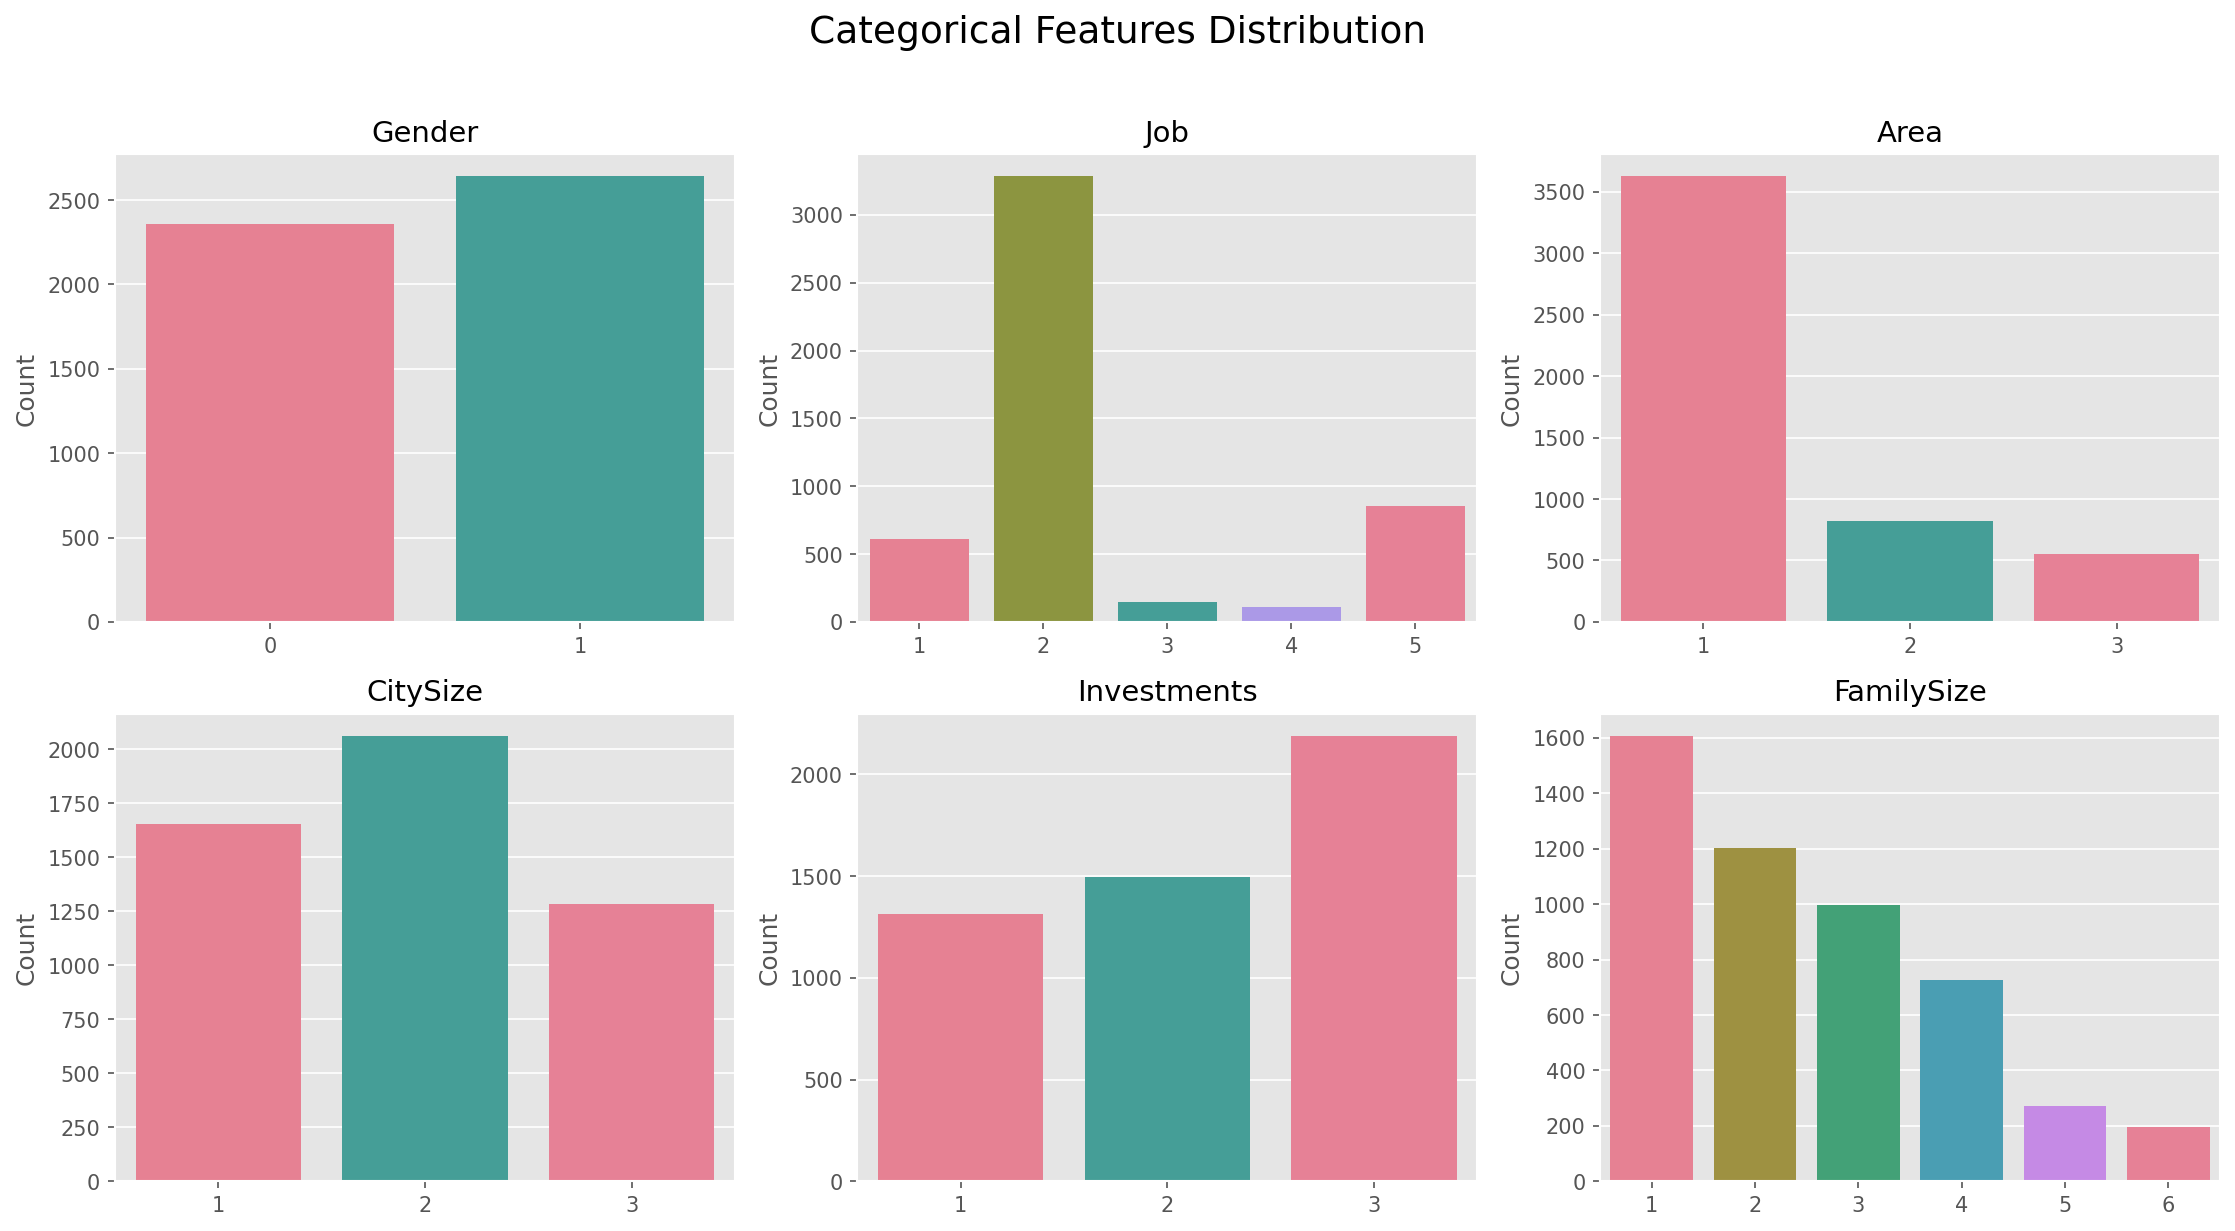

In [3]:
categorical_cols = [
    "Gender",
    "Job",
    "Area",
    "CitySize",
    "Investments",
    "FamilySize",
]
numeric_cols = [
    "Age",
    "Income",
    "Wealth",
    "Debt",
    "FinEdu",
    "ESG",
    "Digital",
    "BankFriend",
    "LifeStyle",
    "Luxury",
    "Saving",
]


plt.figure(figsize=(15, 8))
plt.suptitle("Categorical Features Distribution", fontsize=18, y=1.02)

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=data, x=col, hue=col, palette="husl", legend=False)
    plt.title(f"{col}", fontsize=14)
    plt.ylabel("Count")
    plt.xlabel("")

plt.tight_layout()
plt.show()

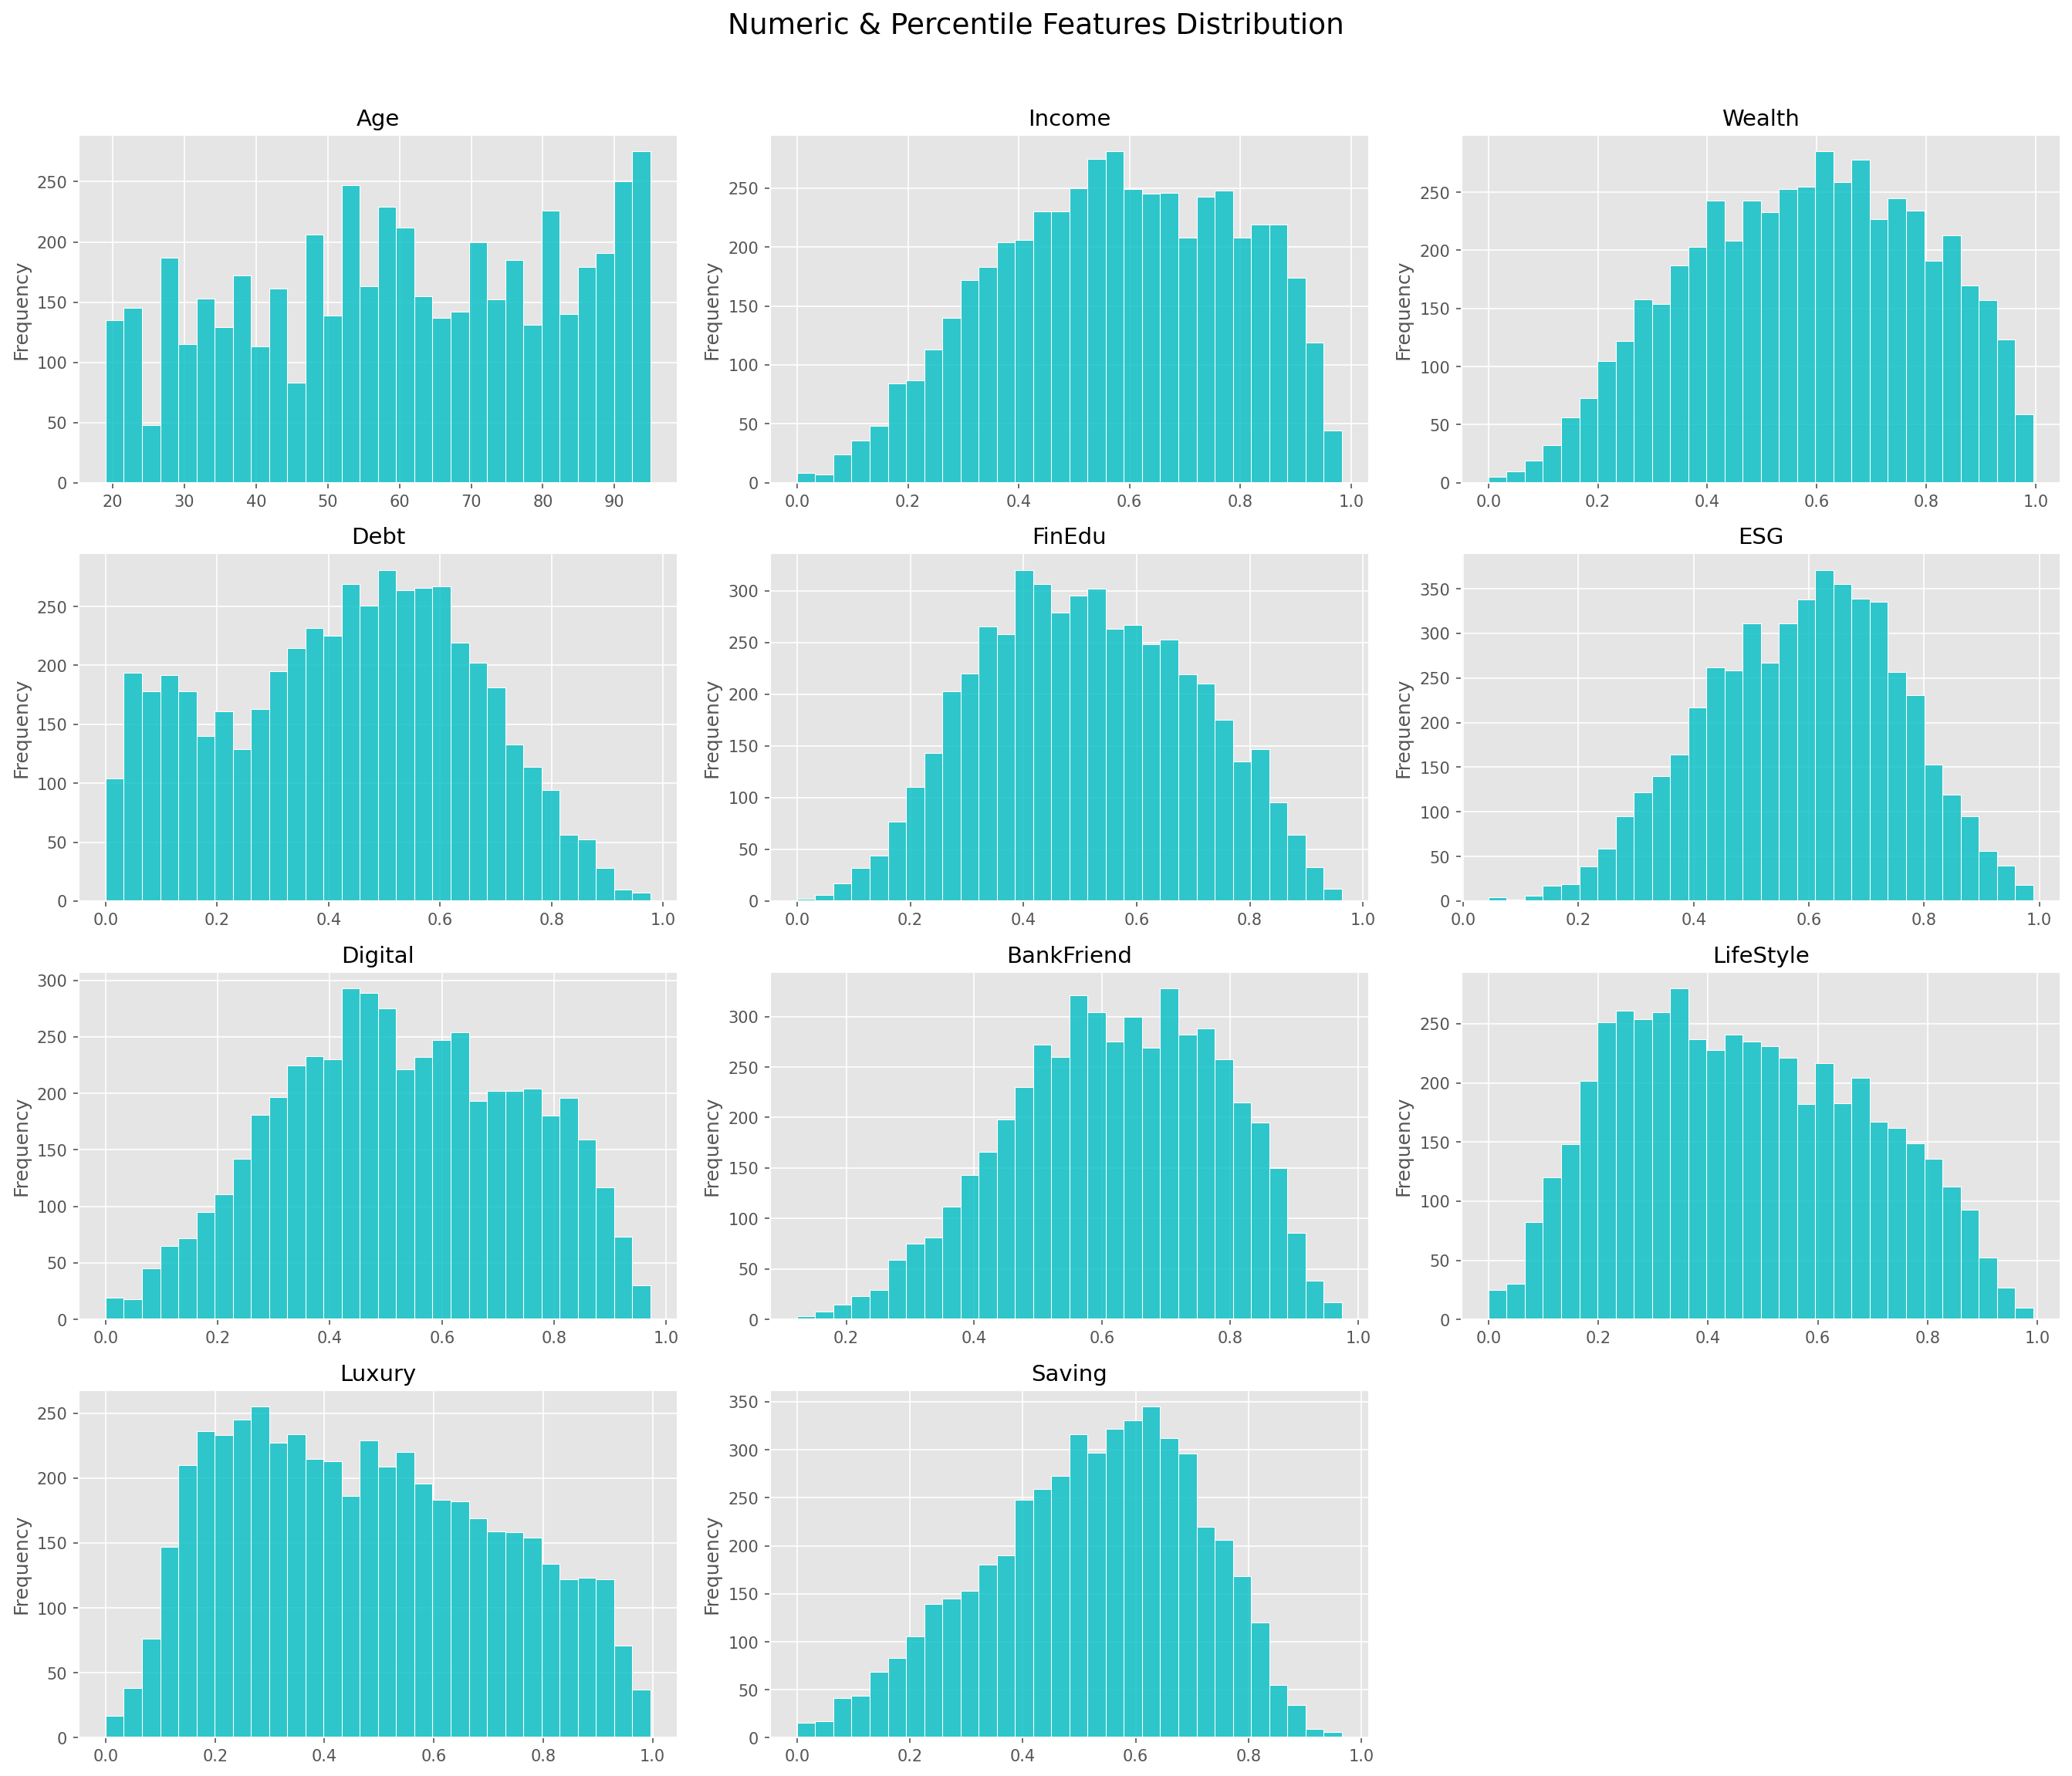

In [4]:
plt.figure(figsize=(18, 15))
plt.suptitle("Numeric & Percentile Features Distribution", fontsize=18, y=1.02)

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 3, i)
    sns.histplot(
        data=data, x=col, bins=30, color="#00BFC4", edgecolor="white", alpha=0.8
    )
    plt.title(f"{col}", fontsize=14)
    plt.ylabel("Frequency")
    plt.xlabel("")

plt.tight_layout()
plt.show()

The numerical variables generally follow a normal distribution, with no significant kurtosis and Skewness observed.


### Correlation


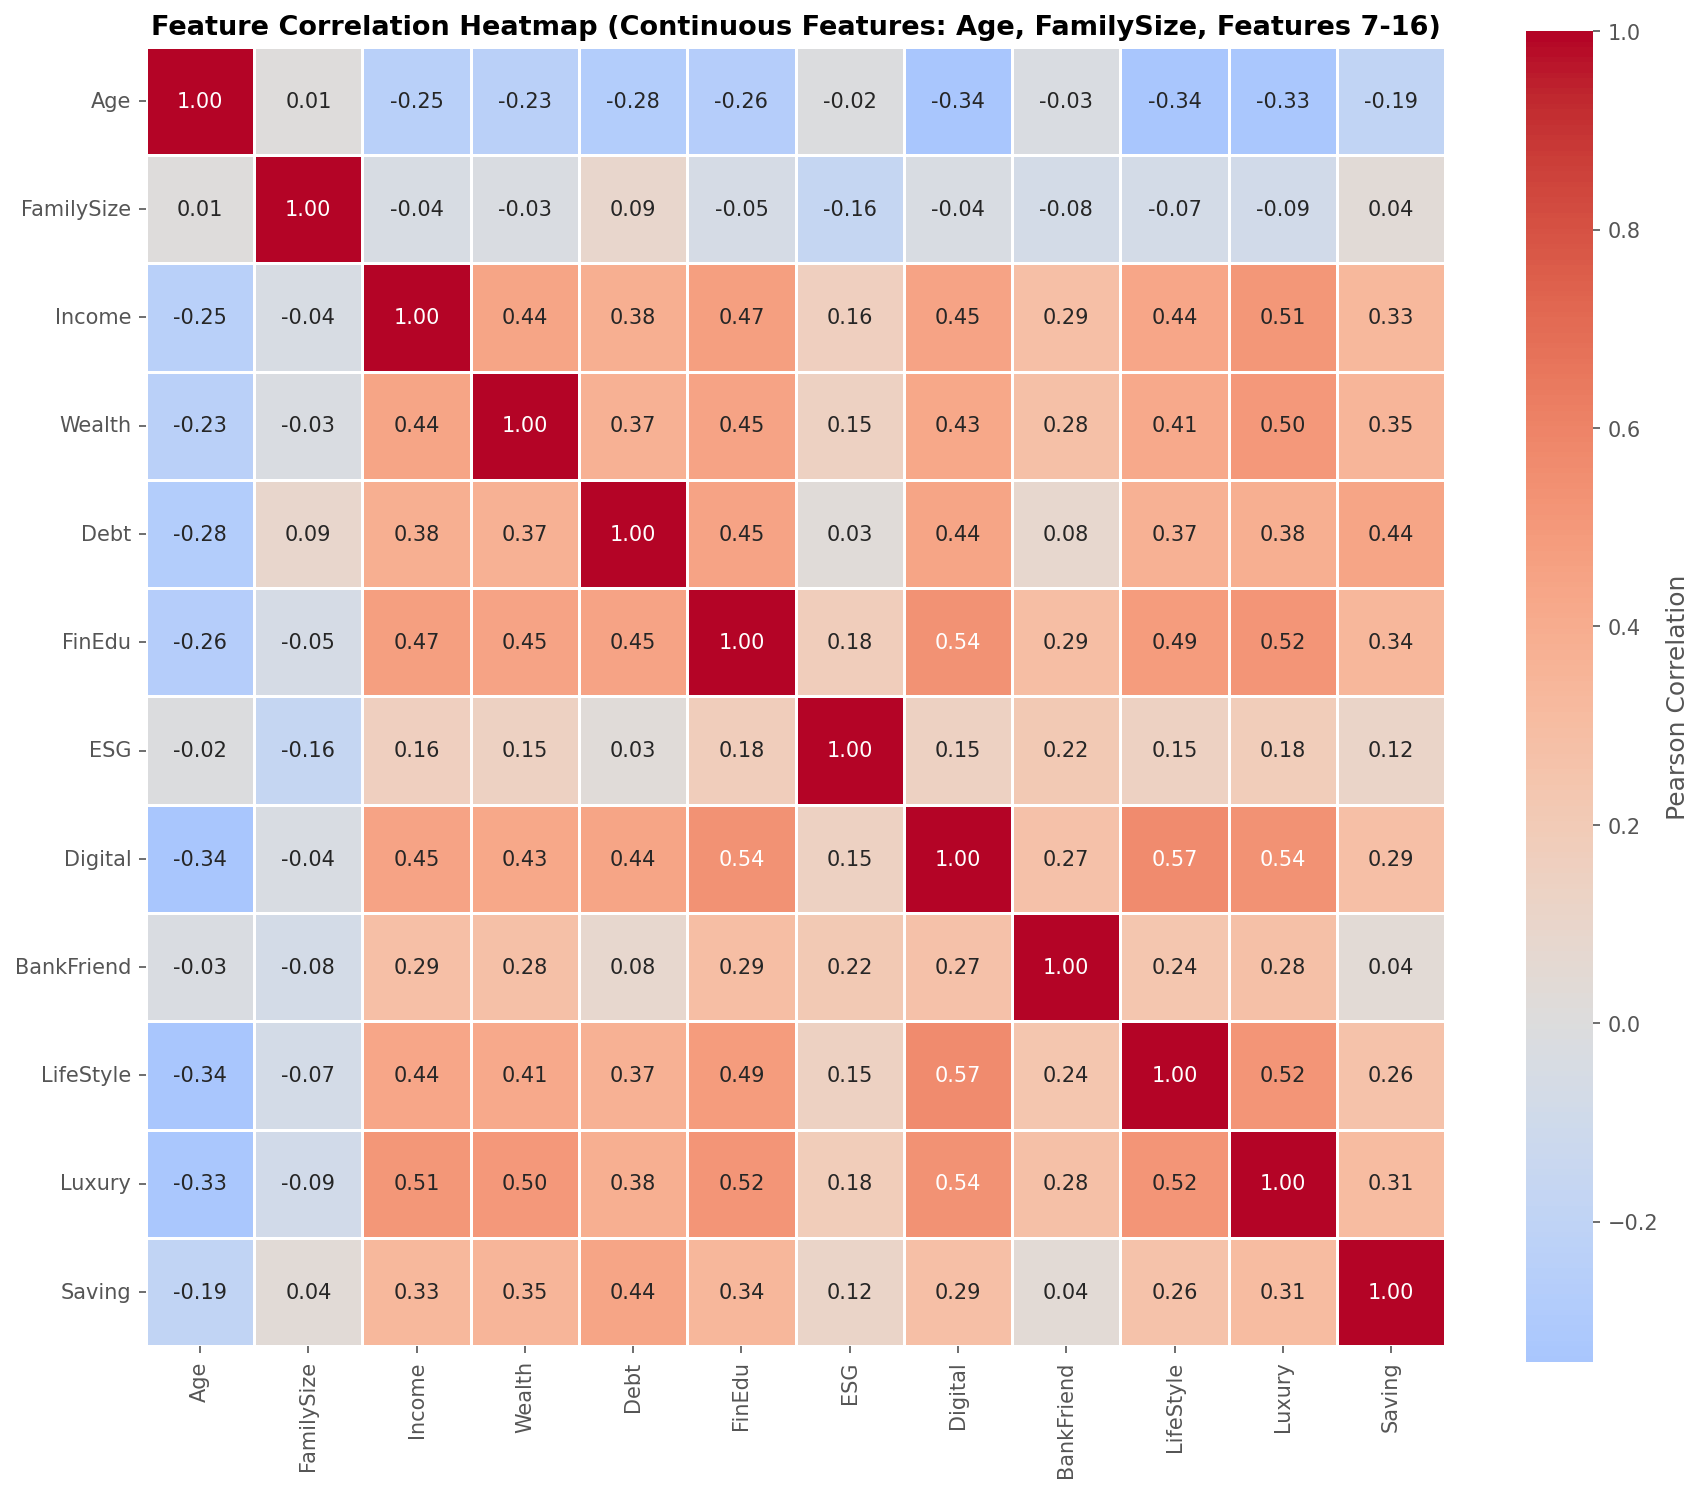

Strong Correlations Detected (|r| > 0.5):
  Digital      vs LifeStyle    | r = +0.567 (positive)
  Digital      vs Luxury       | r = +0.539 (positive)
  FinEdu       vs Digital      | r = +0.536 (positive)
  LifeStyle    vs Luxury       | r = +0.523 (positive)
  FinEdu       vs Luxury       | r = +0.517 (positive)
  Income       vs Luxury       | r = +0.512 (positive)
  Wealth       vs Luxury       | r = +0.502 (positive)

Multicollinearity Note:
  In downstream regression, consider removing one variable from each strongly
  correlated pair (or use regularization/VIF checks) to reduce multicollinearity.


In [5]:
continuous_features = [
    "Age",
    "FamilySize",
    "Income",
    "Wealth",
    "Debt",
    "FinEdu",
    "ESG",
    "Digital",
    "BankFriend",
    "LifeStyle",
    "Luxury",
    "Saving",
]

available_features = [c for c in continuous_features if c in data.columns]
missing_features = [c for c in continuous_features if c not in data.columns]

X = data[available_features].copy()
investments = data["Investments"].copy()

# Pearson Correlation Heatmap
corr_matrix = X.corr(method="pearson")
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Pearson Correlation"},
)
plt.title(
    "Feature Correlation Heatmap (Continuous Features: Age, FamilySize, Features 7-16)",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

# Business Insights and Risk Detection (correlation > 0.5)
threshold = 0.5
strong_pairs = []
for i, col1 in enumerate(corr_matrix.columns):
    for j, col2 in enumerate(corr_matrix.columns):
        if j <= i:
            continue
        corr_val = corr_matrix.loc[col1, col2]
        if abs(corr_val) > threshold:
            relation = "positive" if corr_val > 0 else "negative"
            strong_pairs.append((col1, col2, corr_val, relation))

strong_pairs = sorted(strong_pairs, key=lambda x: abs(x[2]), reverse=True)

print(f"Strong Correlations Detected (|r| > {threshold}):")
print("=" * 72)
if strong_pairs:
    for col1, col2, corr_val, relation in strong_pairs:
        print(f"  {col1:12s} vs {col2:12s} | r = {corr_val:+.3f} ({relation})")
    print("\nMulticollinearity Note:")
    print(
        "  In downstream regression, consider removing one variable from each strongly"
    )
    print(
        "  correlated pair (or use regularization/VIF checks) to reduce multicollinearity."
    )
else:
    print("  No pairs exceeded the threshold.")

With current threshold 0.8, multicollinearity removal is not immediately required from this feature set.


### 2D reduction



PCA explained variance: PC1=36.68%, PC2=11.04%
t-SNE computed on a random sample of 2000 points out of 5000.


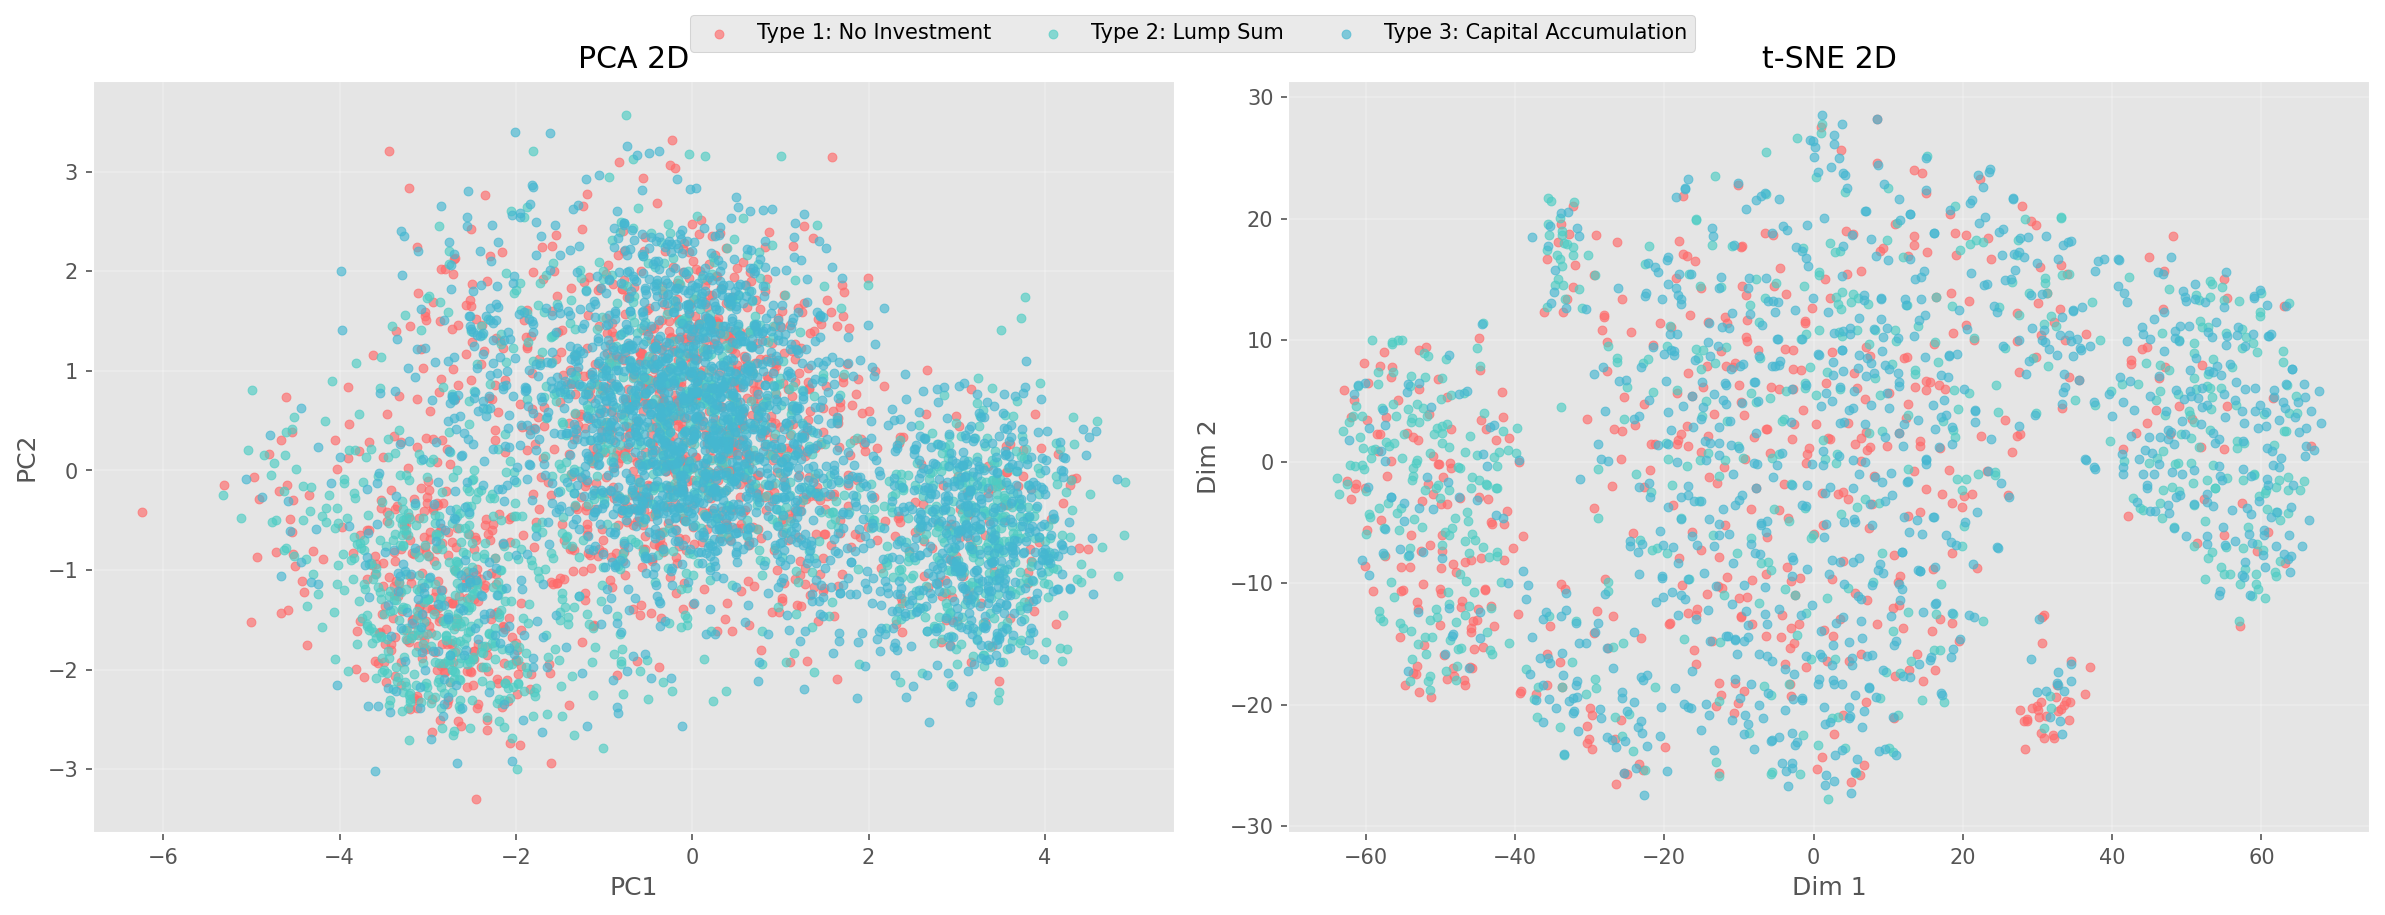

In [6]:
# Initial 2D reduction before clustering: PCA and t-SNE
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_scaled)
explained = pca_2d.explained_variance_ratio_
print(f"\nPCA explained variance: PC1={explained[0]:.2%}, PC2={explained[1]:.2%}")

# t-SNE can be expensive on large data; sample for responsiveness if needed.
max_tsne_points = 2000
if len(X_scaled) > max_tsne_points:
    sample_idx = np.random.default_rng(42).choice(
        len(X_scaled), size=max_tsne_points, replace=False
    )
    X_tsne_input = X_scaled[sample_idx]
    investments_tsne = investments.iloc[sample_idx]
    print(
        f"t-SNE computed on a random sample of {max_tsne_points} points out of {len(X_scaled)}."
    )
else:
    X_tsne_input = X_scaled
    investments_tsne = investments

tsne_2d = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42,
    max_iter=1000,
)
X_tsne = tsne_2d.fit_transform(X_tsne_input)

investment_labels = {
    1: "Type 1: No Investment",
    2: "Type 2: Lump Sum",
    3: "Type 3: Capital Accumulation",
}
plot_palette = {1: "#FF6B6B", 2: "#4ECDC4", 3: "#45B7D1"}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA scatter
for inv_type in sorted(investments.unique()):
    mask = investments == inv_type
    axes[0].scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=18,
        alpha=0.65,
        color=plot_palette.get(inv_type, "gray"),
        label=investment_labels.get(inv_type, f"Type {inv_type}"),
    )
axes[0].set_title("PCA 2D")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].grid(alpha=0.25)

# t-SNE scatter
for inv_type in sorted(investments_tsne.unique()):
    mask = investments_tsne == inv_type
    axes[1].scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        s=18,
        alpha=0.65,
        color=plot_palette.get(inv_type, "gray"),
        label=investment_labels.get(inv_type, f"Type {inv_type}"),
    )
axes[1].set_title("t-SNE 2D")
axes[1].set_xlabel("Dim 1")
axes[1].set_ylabel("Dim 2")
axes[1].grid(alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, 1.02),
)
plt.tight_layout()
plt.show()

## Data Load & Preprocessing


We keep the preprocessing logic explicit because clustering quality depends heavily on feature treatment.

- For **K-Medoids + Gower**, categorical variables are kept as categorical (no one-hot expansion), and only continuous variables are min-max scaled.
- For **Bayesian Gaussian Mixture**, categorical variables are one-hot encoded and continuous variables are standardized with `StandardScaler`.
- Internal validation is matched to each algorithm's geometry/metric.


In [3]:
mapping_dicts = {
    "Gender": {"0": "Male", "1": "Female", "0.0": "Male", "1.0": "Female"},
    "Job": {
        "1": "Unemployed",
        "2": "Employee/Worker",
        "3": "Manager/Executive",
        "4": "Entrepreneur/Freelancer",
        "5": "Retired",
    },
    "Area": {"1": "Nord", "2": "Centro", "3": "Sud/Isole"},
    "CitySize": {"1": "Small town", "2": "Medium-sized city", "3": "Large city"},
    "Investments": {
        "1": "No investments",
        "2": "Mostly lump sum",
        "3": "Capital accumulation",
    },
}

# Load data and remove the ID key because it has no clustering signal.
data = pd.read_excel("./Dataset1_BankClients.xlsx")
data = data.drop(columns=["ID"])

categorical_columns = ["Gender", "Job", "Area", "CitySize", "Investments"]
continuous_columns = [col for col in data.columns if col not in categorical_columns]

# K-Medoids + Gower: keep original mixed feature representation.
data_scaled_kmedoids = data.copy()

# Scale only continuous variables for the numeric part of Gower distance.
scaler_0 = MinMaxScaler()
data_scaled_kmedoids[continuous_columns] = scaler_0.fit_transform(
    data_scaled_kmedoids[continuous_columns]
)

# Explicitly mark categorical features for gower_matrix.
cat_feature_mask = [col in categorical_columns for col in data_scaled_kmedoids.columns]

# Bayesian mixture uses one-hot encoded inputs.
data_encoded = pd.get_dummies(data, columns=categorical_columns, dtype=int)

In [8]:
print("K-Medoids preprocessing check")
print("=" * 40)
print("Categorical features passed to Gower:")
print(dict(zip(data_scaled_kmedoids.columns, cat_feature_mask)))

print("\nPreview of mixed-type K-Medoids input:")
data_scaled_kmedoids.head()

K-Medoids preprocessing check
Categorical features passed to Gower:
{'Age': False, 'Gender': True, 'Job': True, 'Area': True, 'CitySize': True, 'FamilySize': False, 'Income': False, 'Wealth': False, 'Debt': False, 'FinEdu': False, 'ESG': False, 'Digital': False, 'BankFriend': False, 'LifeStyle': False, 'Luxury': False, 'Saving': False, 'Investments': True}

Preview of mixed-type K-Medoids input:


,Age,Gender,Job,Area,CitySize,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving,Investments
0,0.065789,1,1,2,2,0.6,0.679599,0.705895,0.268264,0.770735,0.465122,0.718914,0.581720,0.612604,0.901051,0.293334,1
1,0.368421,1,2,2,3,0.0,0.873299,0.919090,0.747693,0.892883,0.521675,0.986877,0.778748,0.868977,0.917477,0.850925,3
2,0.250000,0,2,1,2,0.2,0.942846,0.902289,0.451701,0.504873,0.640388,0.772055,0.677446,0.761279,0.768338,0.521778,3
3,0.631579,0,2,1,2,0.4,0.548115,0.425051,0.614591,0.512343,0.518146,0.607305,0.648808,0.337033,0.519331,0.715921,2
4,0.184211,0,2,1,3,0.0,0.820609,0.734639,0.851100,0.889625,0.783674,0.730646,0.746853,0.915946,0.614119,0.637907,2


In [4]:
# Standard scaling for Bayesian Gaussian Mixture.
scaler_1 = StandardScaler()
data_scaled_bayesian = data_encoded.copy()
data_scaled_bayesian[continuous_columns] = scaler_1.fit_transform(
    data_scaled_bayesian[continuous_columns]
)

data_scaled_bayesian.head()

,Age,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,...,Job_5,Area_1,Area_2,Area_3,CitySize_1,CitySize_2,CitySize_3,Investments_1,Investments_2,Investments_3
0,-1.670489,1.073958,0.433001,0.575951,-0.748623,1.235010,-0.617483,0.800065,-0.004974,0.657254,...,0,0,1,0,0,1,0,1,0,0
1,-0.616420,-1.057475,1.327150,1.565361,1.346014,1.864025,-0.298538,2.017936,1.025961,1.806599,...,0,0,1,0,0,0,1,0,0,1
2,-1.028882,-0.346997,1.648189,1.487387,0.052818,-0.134078,0.370969,1.041585,0.495903,1.323776,...,0,1,0,0,0,1,0,0,0,1
3,0.300162,0.363481,-0.173947,-0.727400,0.764487,-0.095609,-0.318441,0.292808,0.346059,-0.578159,...,0,1,0,0,0,1,0,0,1,0
4,-1.258027,-1.057475,1.083924,0.709348,1.797800,1.847244,1.179065,0.853386,0.859074,2.017167,...,0,1,0,0,0,0,1,0,1,0


## Clustering


### K-Medoids Method

K-Medoids is used here because it is robust for **mixed numerical + categorical data** when we work with a **precomputed Gower distance matrix**.

Method summary:

1. Build one Gower matrix on the mixed-feature table (continuous features min-max scaled, categorical features flagged).
2. Fit K-Medoids for candidate values of $k$ and evaluate with distance-compatible criteria.
3. Select $k$ primarily with silhouette and keep inertia as a compactness diagnostic.
4. Refit the final K-Medoids model with the selected $k$ and use those labels for profiling and visualization.

Distance-compatible metrics used in this section:

- **Silhouette score** with `metric="precomputed"` (higher is better).
- **K-Medoids inertia** (sum of distances to medoids, lower is better).

Calinski-Harabasz and Davies-Bouldin are intentionally not used here because they assume Euclidean feature-space geometry rather than a precomputed mixed-distance matrix.


In [22]:
# Evaluate K-Medoids over a grid of k values using a precomputed Gower distance matrix.
k_values = list(range(3, 15))

# Compute Gower once and reuse it across all candidate models.
gower_distances = gower.gower_matrix(
    data_scaled_kmedoids,
    cat_features=cat_feature_mask,
)

rows = []
for k in k_values:
    model_k = KMedoids(
        n_clusters=k,
        metric="precomputed",
        method="pam",
        init="k-medoids++",
        random_state=42,
    )
    model_k.fit(gower_distances)

    labels_k = model_k.labels_
    sil_k = silhouette_score(gower_distances, labels_k, metric="precomputed")
    inertia_k = float(model_k.inertia_)

    rows.append(
        {
            "k": k,
            "silhouette": float(sil_k),
            "inertia": inertia_k,
        }
    )

kmed_eval_df = pd.DataFrame(rows).sort_values("k").reset_index(drop=True)

# Keep these arrays for downstream compatibility with existing plotting cells.
sil_scores = kmed_eval_df["silhouette"].to_list()
inertia_scores = kmed_eval_df["inertia"].to_list()

best_idx = int(kmed_eval_df["silhouette"].idxmax())
best_k = int(kmed_eval_df.loc[best_idx, "k"])

# Refit final model at selected k.
kmedoids_best = KMedoids(
    n_clusters=best_k,
    metric="precomputed",
    method="pam",
    init="k-medoids++",
    random_state=42,
    max_iter=300,
)
kmedoids_best.fit(gower_distances)
labels = kmedoids_best.labels_

print("K-Medoids model selection summary")
print("=" * 40)
print(kmed_eval_df.to_string(index=False))
print()
print(f"Selected k (max silhouette): {best_k}")
print(f"Silhouette at selected k: {kmed_eval_df.loc[best_idx, 'silhouette']:.4f}")
print(f"Inertia at selected k: {kmed_eval_df.loc[best_idx, 'inertia']:.4f}")

K-Medoids model selection summary
 k  silhouette     inertia
 3    0.142725 1083.485596
 4    0.143046 1013.405273
 5    0.135844  975.046875
 6    0.116270  944.421509
 7    0.118007  917.561829
 8    0.114964  892.676941
 9    0.112726  876.405884
10    0.112811  861.795410
11    0.116293  847.615540
12    0.115149  835.817505
13    0.118843  821.923096
14    0.121615  811.604858

Selected k (max silhouette): 4
Silhouette at selected k: 0.1430
Inertia at selected k: 1013.4053


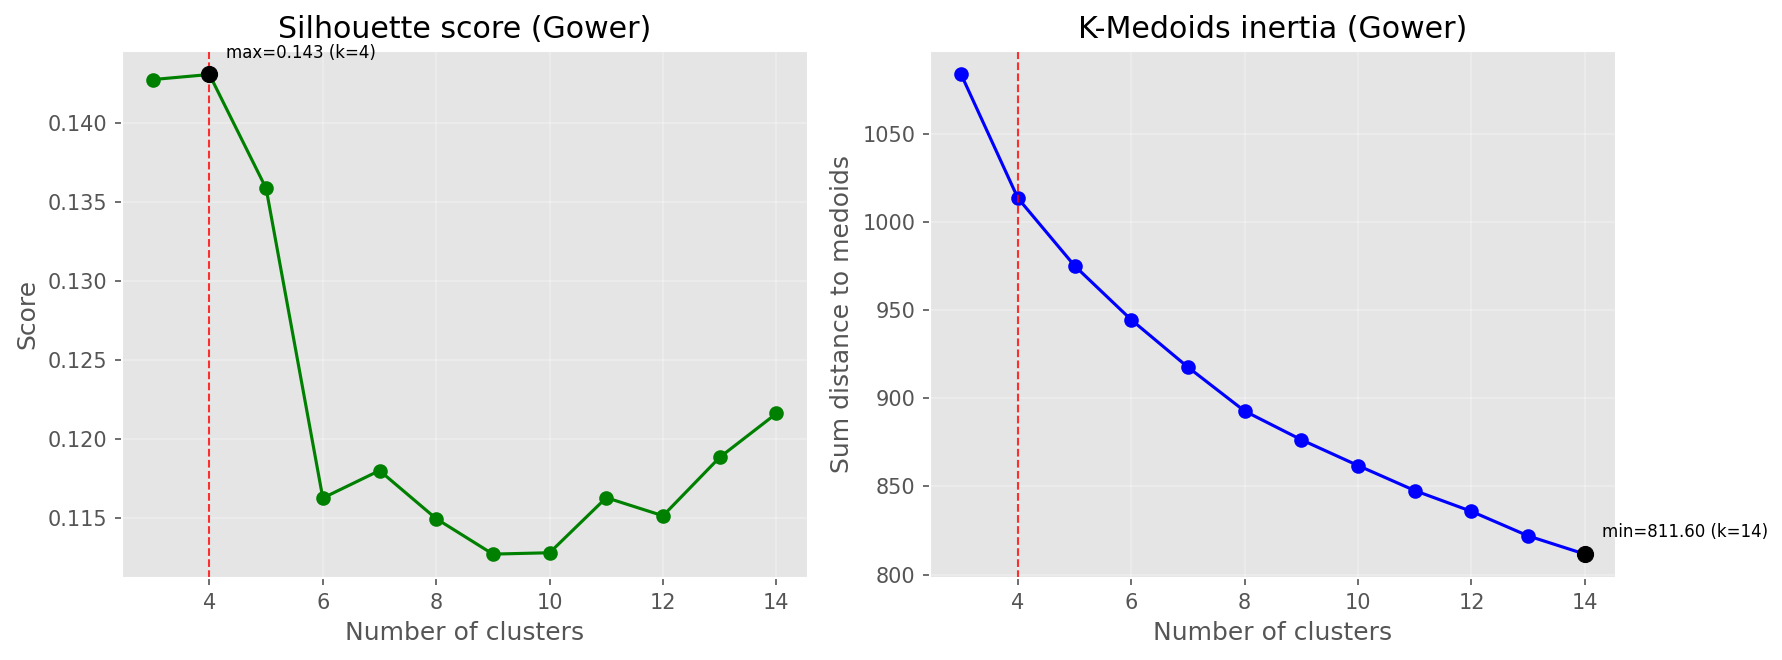

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Silhouette (higher is better).
ax1.plot(k_values, sil_scores, "go-")
ax1.set_title("Silhouette score (Gower)")
ax1.set_xlabel("Number of clusters")
ax1.set_ylabel("Score")
ax1.grid(True, alpha=0.3)

sil_max_idx = int(np.argmax(sil_scores))
sil_k_max = k_values[sil_max_idx]
sil_max = sil_scores[sil_max_idx]
ax1.scatter(sil_k_max, sil_max, color="black", s=60, zorder=5)
ax1.annotate(
    f"max={sil_max:.3f} (k={sil_k_max})",
    (sil_k_max, sil_max),
    textcoords="offset points",
    xytext=(8, 8),
    fontsize=8,
    color="black",
)

# Inertia / medoid cost (lower is better).
ax2.plot(k_values, inertia_scores, "bo-")
ax2.set_title("K-Medoids inertia (Gower)")
ax2.set_xlabel("Number of clusters")
ax2.set_ylabel("Sum distance to medoids")
ax2.grid(True, alpha=0.3)

inertia_min_idx = int(np.argmin(inertia_scores))
inertia_k_min = k_values[inertia_min_idx]
inertia_min = inertia_scores[inertia_min_idx]
ax2.scatter(inertia_k_min, inertia_min, color="black", s=60, zorder=5)
ax2.annotate(
    f"min={inertia_min:.2f} (k={inertia_k_min})",
    (inertia_k_min, inertia_min),
    textcoords="offset points",
    xytext=(8, 8),
    fontsize=8,
    color="black",
)

for ax in (ax1, ax2):
    ax.axvline(best_k, color="red", linestyle="--", linewidth=1, alpha=0.8)

plt.tight_layout()
plt.show()

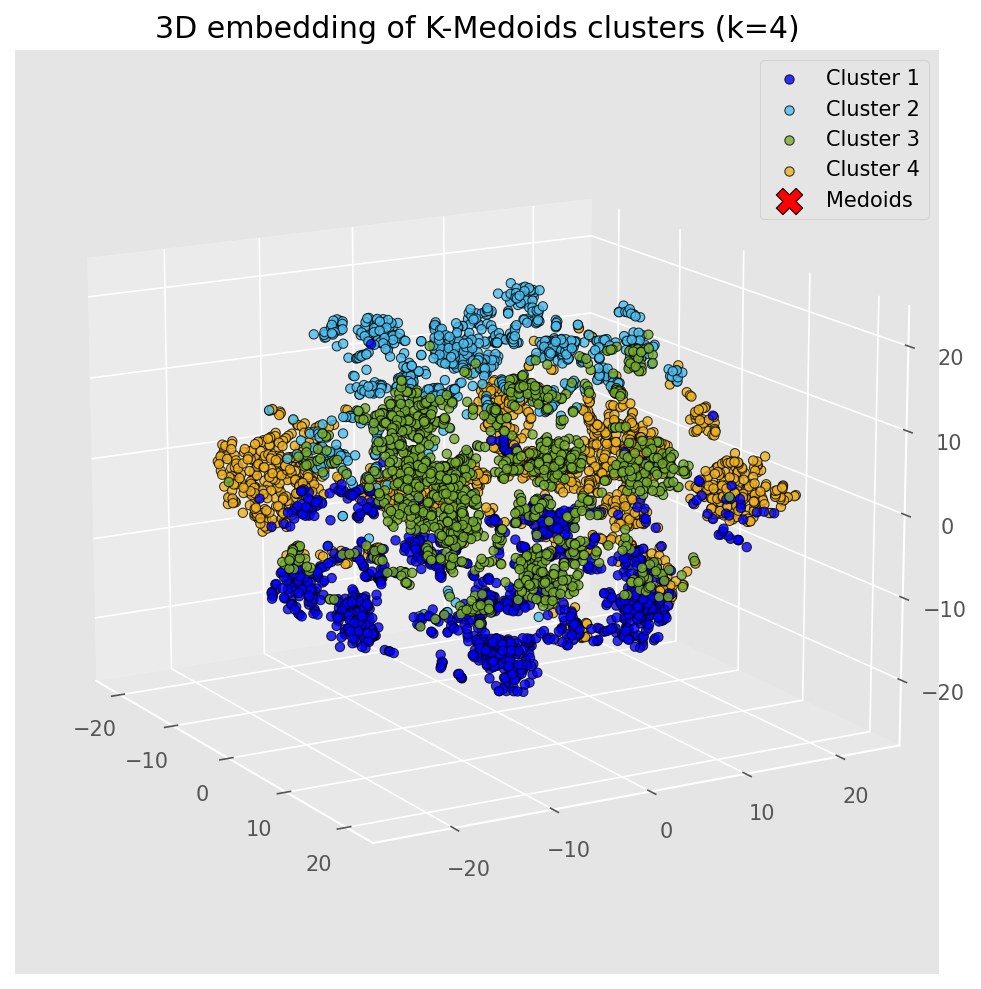

In [24]:
# 3D embedding of the final K-Medoids labels from the selected k.
fig = plt.figure(figsize=(10, 8))
tsne = TSNE(n_components=3, metric="precomputed", random_state=42, init="random")
Y_3d = tsne.fit_transform(gower_distances)

ax = fig.add_subplot(111, projection="3d")
colors = ["blue", "#4DBEEE", "#77AC30", "#EDB120", "#D95319", "#7E2F8E", "#A2142F"]
unique_clusters = np.sort(np.unique(labels))

for idx, cluster_id in enumerate(unique_clusters):
    mask = labels == cluster_id
    ax.scatter(
        Y_3d[mask, 0],
        Y_3d[mask, 1],
        Y_3d[mask, 2],
        c=colors[idx % len(colors)],
        edgecolor="k",
        alpha=0.8,
        label=f"Cluster {int(cluster_id) + 1}",
    )

# Highlight medoids in the embedded space for interpretability.
ax.scatter(
    Y_3d[kmedoids_best.medoid_indices_, 0],
    Y_3d[kmedoids_best.medoid_indices_, 1],
    Y_3d[kmedoids_best.medoid_indices_, 2],
    c="red",
    marker="X",
    s=160,
    edgecolor="k",
    label="Medoids",
)

ax.set_title(f"3D embedding of K-Medoids clusters (k={best_k})")
ax.legend()
ax.view_init(elev=15, azim=-30)
plt.show()

But its rigid boundaries failed to capture the nuanced, overlapping financial behaviors of our clients.
We needed a model that could adapt to complex data shapes and automatically find the optimal number of segments—— Bayesian Gaussian Mixture Model.


### Bayesian Gaussian Mixture Model


In [5]:
# Upper bound on components; Bayesian prior will prune unnecessary ones
max_clusters = 15

bgm = BayesianGaussianMixture(
    n_components=max_clusters,
    covariance_type="full",
    weight_concentration_prior_type="dirichlet_process",
    random_state=42,
    max_iter=1000,
    init_params="kmeans",
)

# Fit on standardized encoded features
bgm.fit(data_scaled_bayesian)

BayesianGaussianMixture(max_iter=1000, n_components=15, random_state=42)

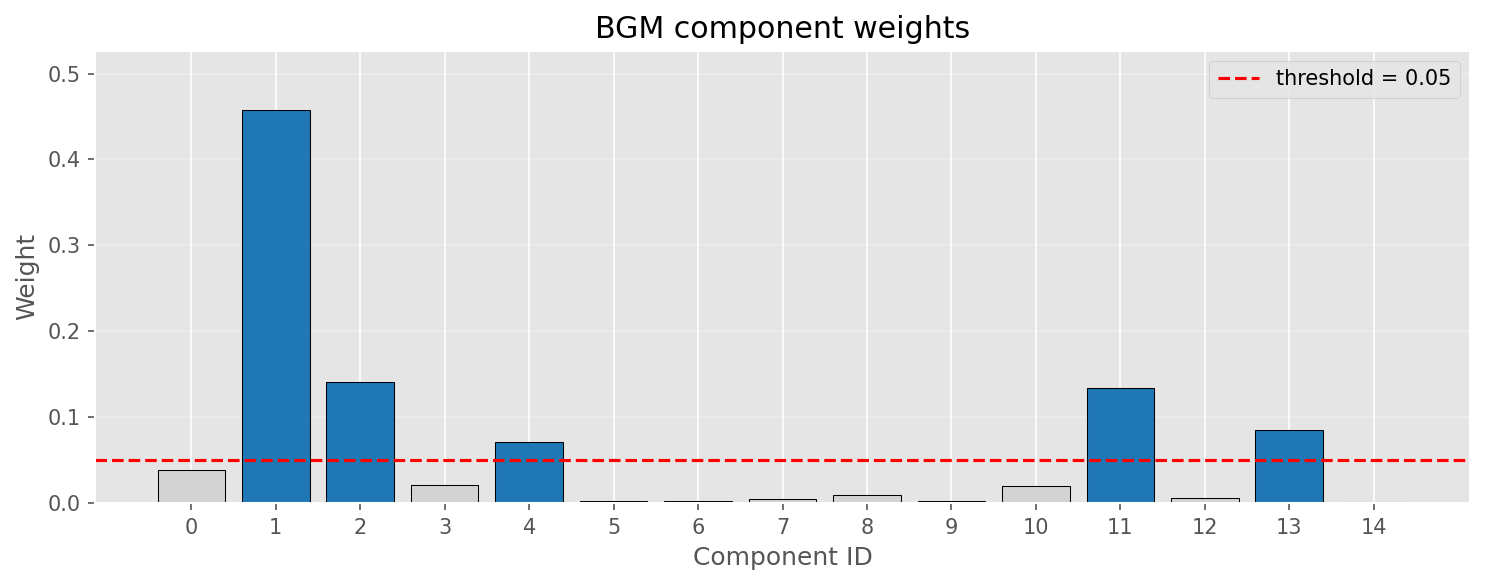

Active components (> 0.05): [1, 2, 4, 11, 13]


In [6]:
raw_labels = bgm.predict(data_scaled_bayesian)
raw_weights = pd.Series(bgm.weights_, name="weight")

weight_threshold = 0.05
active_components = raw_weights[raw_weights > weight_threshold].index.tolist()

# Plot component weights and highlight active components
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(raw_weights))
colors = ["tab:blue" if i in active_components else "lightgray" for i in x]
ax.bar(x, raw_weights.values, color=colors, edgecolor="black", linewidth=0.5)
ax.axhline(
    y=weight_threshold,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"threshold = {weight_threshold:.2f}",
)
ax.set_title("BGM component weights")
ax.set_xlabel("Component ID")
ax.set_ylabel("Weight")
ax.set_xticks(x)
ax.set_ylim(0, max(raw_weights.max() * 1.15, weight_threshold * 1.5))
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Active components (> {weight_threshold:.2f}): {active_components}")

In [15]:
active_mask = pd.Series(raw_labels).isin(active_components)
data_persona = data_scaled_bayesian.loc[active_mask].copy()
data_persona["persona_cluster"] = pd.Series(raw_labels)[active_mask].values

# Remap sparse component IDs to consecutive persona labels.
cluster_remap = {old: new for new, old in enumerate(sorted(active_components))}
data_persona["persona_cluster"] = data_persona["persona_cluster"].map(cluster_remap)

persona_summary = (
    data_persona["persona_cluster"]
    .value_counts(normalize=True)
    .sort_index()
    .rename("share")
    .to_frame()
)
persona_summary["count"] = (
    data_persona["persona_cluster"].value_counts().sort_index().values
)

print(f"Max components (K): {max_clusters}")
print(f"Retained persona frameworks: {len(active_components)}")
print(f"Active original component IDs: {sorted(active_components)}")
persona_summary

Max components (K): 15
Retained persona frameworks: 5
Active original component IDs: [1, 2, 4, 11, 13]


,share,count
persona_cluster,,
0,0.513465,2288
1,0.157989,704
2,0.080117,357
3,0.152154,678
4,0.096275,429


## Qualitative Persona Overlay

To make clusters actionable for business stakeholders, we convert centroids back to interpretable attributes:

- Continuous means are inverse-transformed to original units.
- Dominant categorical values are recovered from one-hot proportions.
- Confidence tags indicate whether each dominant category is clearly represented.


In [16]:
cluster_scaled_means = data_persona.groupby("persona_cluster").mean(numeric_only=True)

continuous_scaled = cluster_scaled_means[continuous_columns]
continuous_original = pd.DataFrame(
    scaler_1.inverse_transform(continuous_scaled),
    columns=continuous_columns,
    index=continuous_scaled.index,
)

categorical_profile = pd.DataFrame(index=cluster_scaled_means.index)
for col in categorical_columns:
    onehot_cols = [c for c in cluster_scaled_means.columns if c.startswith(f"{col}_")]
    if not onehot_cols:
        continue

    proportions = cluster_scaled_means[onehot_cols]
    dominant_onehot = proportions.idxmax(axis=1)
    dominant_value_raw = dominant_onehot.str.replace(f"{col}_", "", regex=False)
    dominant_value_mapped = dominant_value_raw.map(
        lambda x: mapping_dicts.get(col, {}).get(str(x), x)
    )

    categorical_profile[f"{col}_dominant"] = dominant_value_mapped
    categorical_profile[f"{col}_share"] = proportions.max(axis=1)

business_profile = continuous_original.join(categorical_profile)
cluster_count = data_persona["persona_cluster"].value_counts().sort_index()
cluster_share = cluster_count / cluster_count.sum()
business_profile["persona_size"] = (
    cluster_count.reindex(business_profile.index).fillna(0).astype(int)
)
business_profile["persona_share"] = cluster_share.reindex(
    business_profile.index
).fillna(0.0)


def share_confidence_tag(v: float) -> str:
    if v >= 0.75:
        return "High confidence"
    if v >= 0.55:
        return "Medium confidence"
    return "Low confidence"


for col in categorical_columns:
    share_col = f"{col}_share"
    if share_col in business_profile.columns:
        business_profile[f"{col}_confidence"] = business_profile[share_col].apply(
            share_confidence_tag
        )

business_profile

,Age,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,...,CitySize_share,Investments_dominant,Investments_share,persona_size,persona_share,Gender_confidence,Job_confidence,Area_confidence,CitySize_confidence,Investments_confidence
persona_cluster,,,,,,,,,,,,,,,,,,,,,
0,58.723776,2.847902,0.565544,0.572918,0.489046,0.503810,0.545017,0.513323,0.575611,0.443802,...,0.502622,Capital accumulation,0.501311,2288,0.513465,Low confidence,High confidence,Medium confidence,Low confidence,Low confidence
1,53.012784,2.507102,0.599019,0.587074,0.451639,0.517997,0.563484,0.589552,0.582161,0.523466,...,0.663352,Capital accumulation,0.443182,704,0.157989,Medium confidence,Medium confidence,High confidence,Medium confidence,Low confidence
2,80.927171,2.058824,0.368339,0.363737,0.116901,0.332793,0.619582,0.310718,0.645335,0.263214,...,0.481793,Mostly lump sum,0.453782,357,0.080117,High confidence,High confidence,Medium confidence,Low confidence,Low confidence
3,52.346608,2.085546,0.828021,0.834344,0.593841,0.756932,0.671799,0.784804,0.801353,0.709767,...,0.730088,Capital accumulation,0.544248,678,0.152154,Medium confidence,High confidence,High confidence,Medium confidence,Low confidence
4,81.769231,2.130536,0.348933,0.357028,0.113540,0.346101,0.631440,0.328163,0.650396,0.254463,...,0.477855,Mostly lump sum,0.573427,429,0.096275,High confidence,High confidence,Medium confidence,Low confidence,Medium confidence


## Final Clustering Result (5 Personas)

The final clustering solution identifies **5 customer personas** (total \(N = 4456\)).

### Persona 0: Mature Mainstream Working Families

- **Size:** 2288 clients (**51.35%**)
- **Profile:** Average age around 59, medium family size, medium income/wealth, moderate debt.
- **Behavior:** Balanced financial behavior, moderate digital usage, moderate financial education.
- **Dominant traits:** Female, Employee/Worker, Nord, Medium-sized city.
- **Investment style:** Capital accumulation.

### Persona 1: Urban Middle-Aged Female Accumulators

- **Size:** 704 clients (**15.80%**)
- **Profile:** Around 53 years old, smaller families, slightly higher income/wealth than Persona 0.
- **Behavior:** Higher digital adoption and more active lifestyle.
- **Dominant traits:** Female, mostly Employee/Worker, strongly Nord, Large city.
- **Investment style:** Capital accumulation.

### Persona 2: Elderly Male Retirees (Conservative)

- **Size:** 357 clients (**8.01%**)
- **Profile:** Oldest segment (about 81), small households, low income/wealth, very low debt.
- **Behavior:** Low digital engagement, low lifestyle/luxury orientation.
- **Dominant traits:** Male, Retired, Nord, Medium-sized city.
- **Investment style:** Mostly lump sum.

### Persona 3: Affluent Digital Professionals

- **Size:** 678 clients (**15.22%**)
- **Profile:** Around 52 years old, highest income/wealth among all clusters.
- **Behavior:** Highest financial education, strongest digital adoption, high ESG and lifestyle/luxury orientation.
- **Dominant traits:** Mostly Male, Employee/Worker, strongly Nord, Large city.
- **Investment style:** Capital accumulation.

### Persona 4: Elderly Female Retirees (Low-Intensity Banking)

- **Size:** 429 clients (**9.63%**)
- **Profile:** About 82 years old, low income/wealth, low debt.
- **Behavior:** Low digital activity and low lifestyle/luxury propensity.
- **Dominant traits:** Female, Retired, Nord, Medium-sized city.
- **Investment style:** Mostly lump sum.

### Overall Interpretation

The clustering is mainly driven by:

1. **Life stage** (working-age vs retired)
2. **Economic capacity** (mass market vs affluent)
3. **Behavioral engagement** (digital/active vs low-intensity)
4. **Retired segment split by gender** (Persona 2 vs Persona 4)

This segmentation provides a strong basis for targeted strategies in advisory, digital engagement, and product personalization.


## LVQ Modeling on Persona Labels

The LVQ stage provides prototype vectors per persona. These prototypes are useful to summarize each segment and to visualize class geometry.


In [17]:
# Load persona-labeled dataset produced by Bayesian clustering
df = pd.read_excel("./result/bayesian-clustered-bankClients.xlsx")
X = df.drop(columns=["persona_cluster"])
y = df["persona_cluster"]

# Stratified split keeps persona proportions consistent
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# One prototype per class for interpretable LVQ codebook vectors
lvq = GLVQ(
    prototype_init="class-conditional-mean",
    prototype_n_per_class=1,
    random_state=42,
    solver_type="steepest-gradient-descent",
    solver_params={"max_runs": 100},
)
lvq.fit(X_train, y_train)

# Keep train/test predictions for quick diagnostics
y_pred_test = lvq.predict(X_test)
y_pred_train = lvq.predict(X_train)

### Multivariate LVQ prototype visualization and evaluation


In [18]:
# Ensure array form for model-space operations
X_train_np = (
    X_train.to_numpy() if isinstance(X_train, pd.DataFrame) else np.asarray(X_train)
)
X_test_np = (
    X_test.to_numpy() if isinstance(X_test, pd.DataFrame) else np.asarray(X_test)
)
y_train_np = y_train.to_numpy() if hasattr(y_train, "to_numpy") else np.asarray(y_train)
y_test_np = y_test.to_numpy() if hasattr(y_test, "to_numpy") else np.asarray(y_test)

prototypes = np.asarray(lvq.prototypes_)


prototype_labels = np.asarray(lvq.prototypes_labels_, dtype=int)


feature_names = (
    list(X_train.columns)
    if isinstance(X_train, pd.DataFrame)
    else [f"f_{i}" for i in range(X_train_np.shape[1])]
)

prototype_df = pd.DataFrame(prototypes, columns=feature_names)
prototype_df.insert(0, "prototype_class", prototype_labels)


prototype_df.head()

,prototype_class,Age,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,...,Job_5,Area_1,Area_2,Area_3,CitySize_1,CitySize_2,CitySize_3,Investments_1,Investments_2,Investments_3
0,0,-0.090627,0.456944,-0.266142,-0.162754,0.498390,-0.219626,-0.519630,-0.344352,-0.601145,...,-0.169114,0.611615,0.094265,0.294120,0.723614,0.719111,-0.442725,0.359926,0.087425,0.552649
1,1,-0.475131,-0.714487,0.213687,-0.105095,-0.705909,0.011761,0.392619,0.723312,-0.142157,...,-0.105233,1.396342,0.232170,-0.628515,-1.216119,-1.087232,3.303363,0.489518,0.143619,0.366872
2,2,1.235387,-0.601664,-1.047625,-1.354154,-2.338161,-1.408870,0.573051,-1.335143,0.740368,...,1.459318,0.668974,0.286392,0.044634,0.323521,0.484699,0.191781,0.443376,0.419888,0.136736
3,3,-0.409728,-0.608129,1.773684,1.785609,0.873702,1.966648,0.721570,1.846383,1.888835,...,0.086535,1.139873,0.092766,-0.232639,-0.385083,0.078130,1.306953,-0.377955,0.698853,0.679102
4,4,1.348670,-0.531007,-1.457628,-1.462825,-2.280020,-0.937308,0.835135,-1.152197,0.648009,...,1.535310,0.572258,0.384808,0.042934,0.542205,0.379731,0.078064,0.260220,0.950848,-0.211068


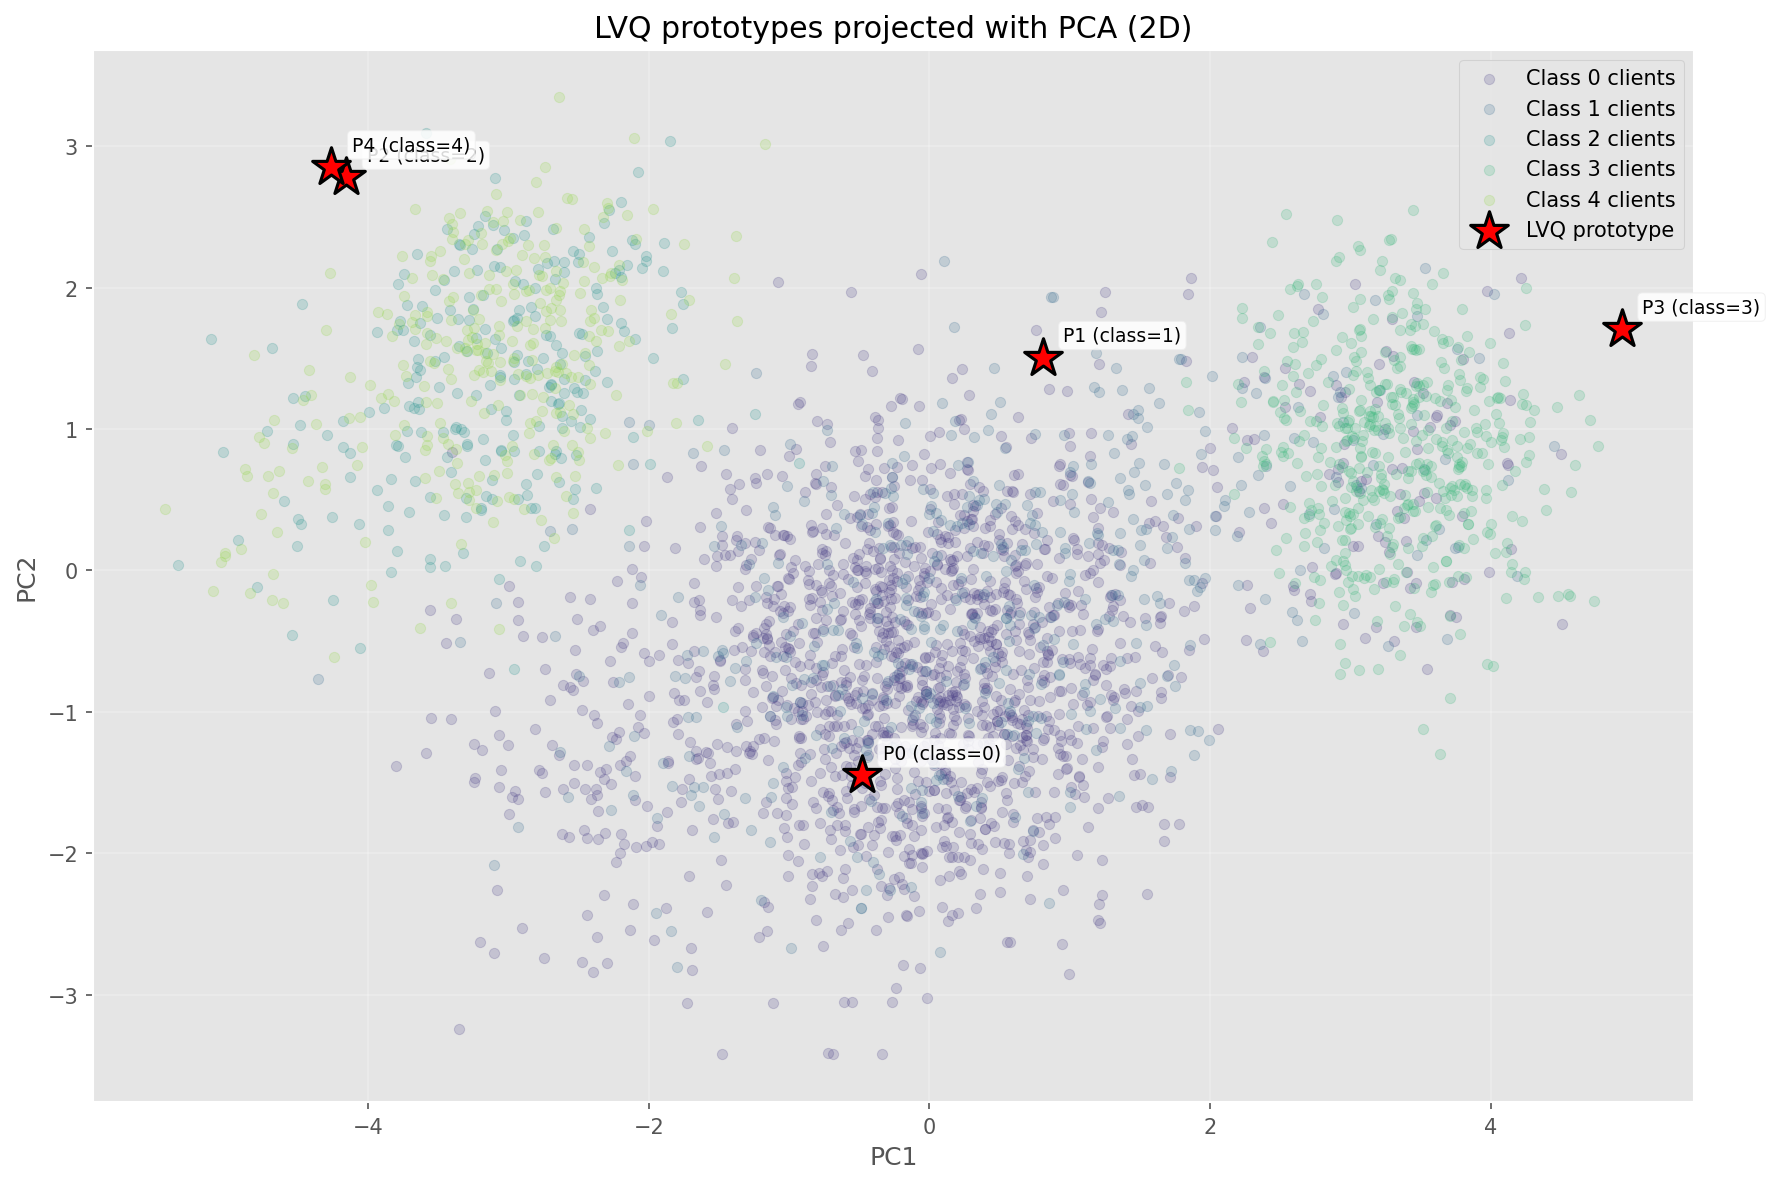

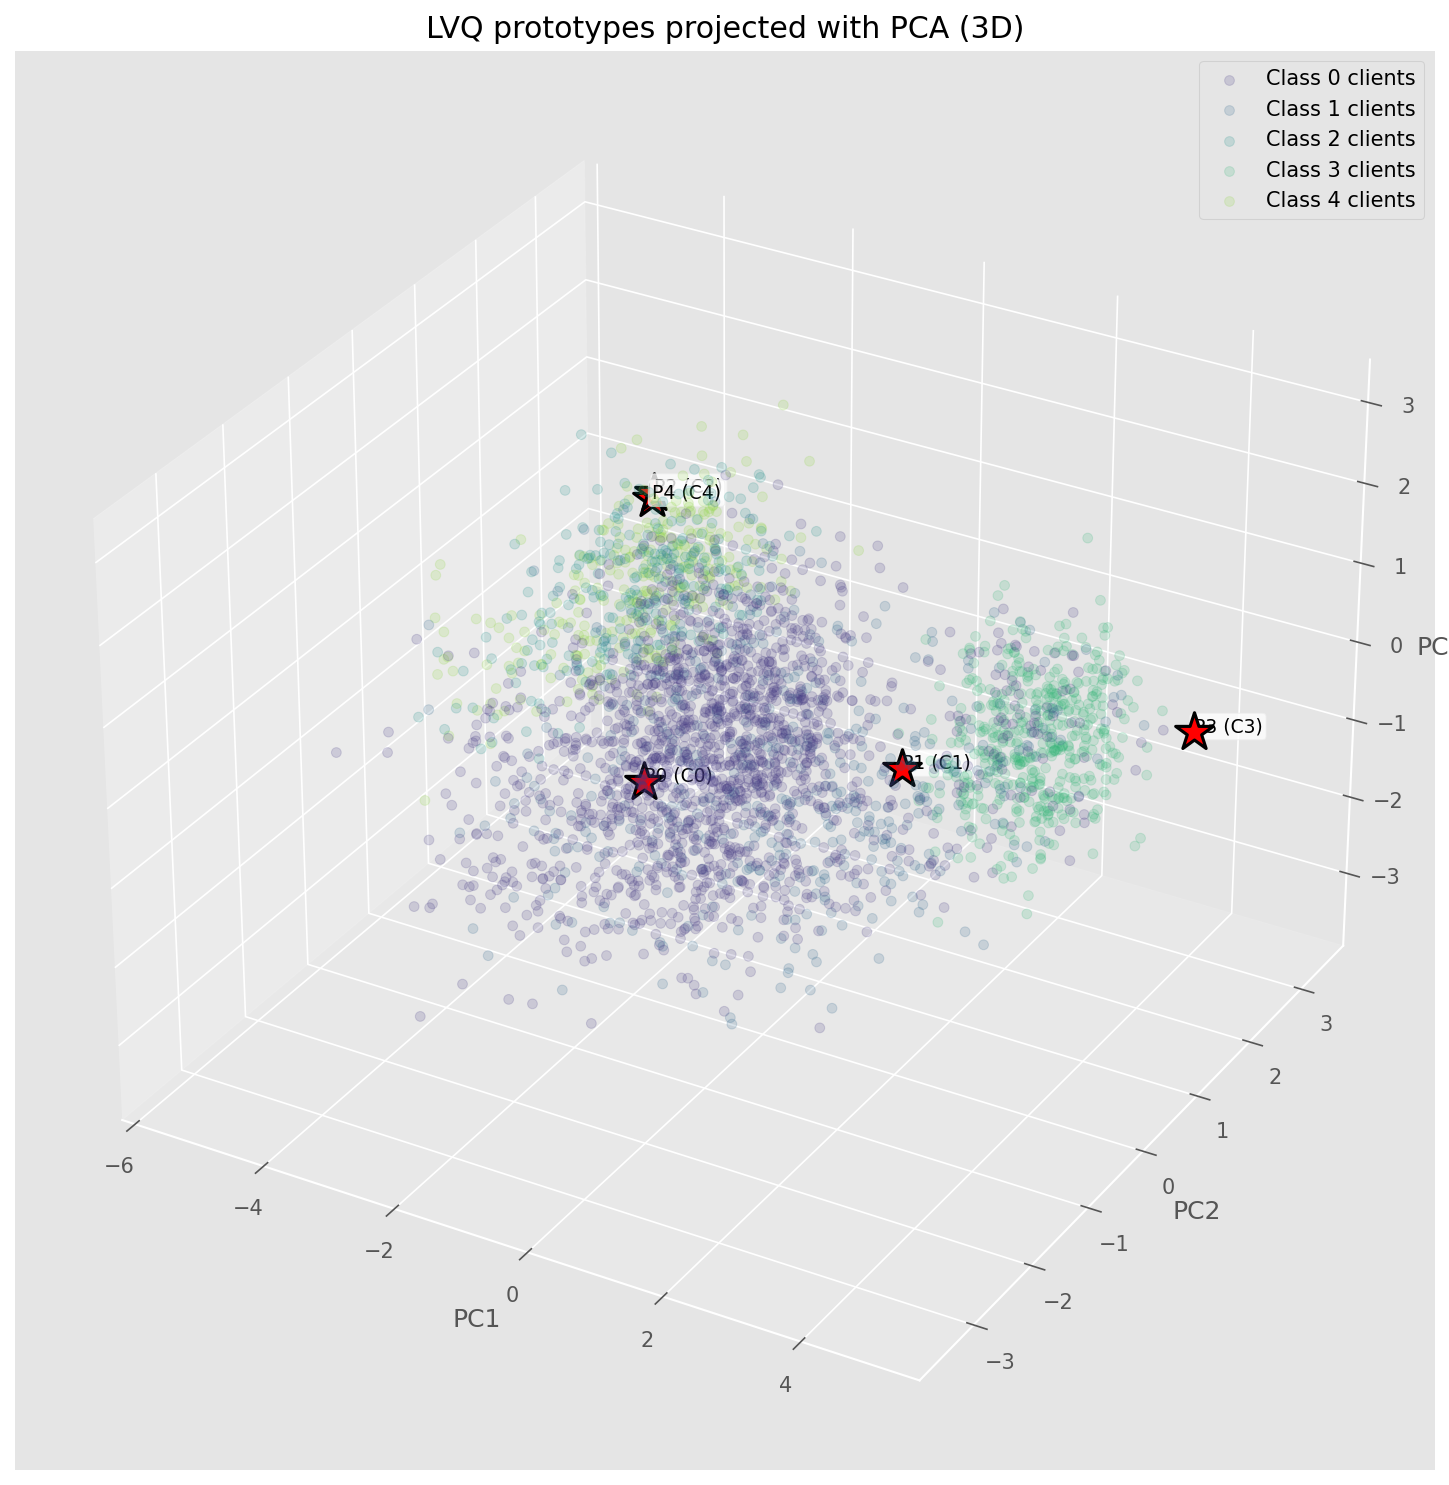

In [19]:
# -----------------------------------------------------------------------------
# 1) 2D PCA projection of clients and prototypes (multivariate -> 2D)
# -----------------------------------------------------------------------------
pca_2d = PCA(n_components=2, random_state=42)
X_train_2d = pca_2d.fit_transform(X_train_np)
prototypes_2d = pca_2d.transform(prototypes)

unique_classes = np.sort(np.unique(y_train_np))
palette = sns.color_palette("viridis", n_colors=len(unique_classes))
color_map = {cls: palette[i] for i, cls in enumerate(unique_classes)}

plt.figure(figsize=(12, 8))

for cls in unique_classes:
    mask = y_train_np == cls
    plt.scatter(
        X_train_2d[mask, 0],
        X_train_2d[mask, 1],
        alpha=0.20,
        s=24,
        color=color_map[cls],
        label=f"Class {cls} clients",
    )

for i, (px, py) in enumerate(prototypes_2d):
    cls = int(prototype_labels[i])
    plt.scatter(
        px,
        py,
        s=360,
        marker="*",
        color="red",
        edgecolor="black",
        linewidth=1.5,
        zorder=5,
        label="LVQ prototype" if i == 0 else "",
    )
    plt.annotate(
        f"P{i} (class={cls})",
        (px, py),
        textcoords="offset points",
        xytext=(10, 8),
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.85),
    )

plt.title("LVQ prototypes projected with PCA (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.25)
plt.legend(loc="best")
plt.tight_layout()
plt.savefig("result/lvq_prototypes_2d_pca.png", dpi=300)
plt.show()

# -----------------------------------------------------------------------------
# 2) 3D PCA projection (multivariate -> 3D)
# -----------------------------------------------------------------------------
pca_3d = PCA(n_components=3, random_state=42)
X_train_3d = pca_3d.fit_transform(X_train_np)
prototypes_3d = pca_3d.transform(prototypes)

fig = plt.figure(figsize=(13, 10))
ax = fig.add_subplot(111, projection="3d")

for cls in unique_classes:
    mask = y_train_np == cls
    ax.scatter(
        X_train_3d[mask, 0],
        X_train_3d[mask, 1],
        X_train_3d[mask, 2],
        alpha=0.18,
        s=22,
        color=color_map[cls],
        label=f"Class {cls} clients",
    )

for i, (px, py, pz) in enumerate(prototypes_3d):
    cls = int(prototype_labels[i])
    ax.scatter(
        px,
        py,
        pz,
        s=360,
        marker="*",
        color="red",
        edgecolor="black",
        linewidth=1.5,
        zorder=5,
    )
    ax.text(
        px,
        py,
        pz,
        f"P{i} (C{cls})",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8),
    )

ax.set_title("LVQ prototypes projected with PCA (3D)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.legend(loc="best")
plt.tight_layout()
plt.savefig("result/lvq_prototypes_3d_pca.png", dpi=300)
plt.show()

Notably, while Persona 2 (Elderly Male Retirees) and Persona 4 (Elderly Female Retirees) exhibit significant spatial overlap due to nearly identical financial profiles—low wealth, low debt, and low digital activity—the model successfully bifurcates them by gender.

While these "Twin Segments" share similar product needs (e.g., lump-sum investments), their communication channels and long-term legacy planning should be gender-nuanced to maximize advisory resonance.


## Decision Tree Model for Inference

To enable fast operational scoring, we train a Decision Tree on the persona labels and provide an inference helper that accepts a feature dictionary.

- Inputs are automatically aligned to training columns.
- The function returns predicted persona and class probabilities.


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    data_persona.drop(columns=["persona_cluster"]),
    data_persona["persona_cluster"],
    test_size=0.2,
    random_state=42,
)
dt_model = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
)
dt_model.fit(X_train, y_train)

dt_pred_test = dt_model.predict(X_test)
dt_pred_train = dt_model.predict(X_train)

print("Decision Tree Evaluation")
print(f"Training accuracy: {accuracy_score(y_train, dt_pred_train):.4f}")
print(f"Testing accuracy: {accuracy_score(y_test, dt_pred_test):.4f}")
print("\nClassification Report")
print(classification_report(y_test, dt_pred_test))

feature_order = list(X_train.columns)


def infer_persona_decision_tree(input_features: dict) -> dict:
    row = pd.DataFrame([input_features]).reindex(columns=feature_order, fill_value=0)
    pred = int(dt_model.predict(row)[0])
    proba = dt_model.predict_proba(row)[0]
    class_probs = {int(cls): float(p) for cls, p in zip(dt_model.classes_, proba)}
    return {
        "predicted_persona": pred,
        "confidence": float(np.max(proba)),
        "class_probabilities": class_probs,
    }


# Example inference using one record from the test set.
sample_payload = X_test.iloc[0].to_dict()
infer_persona_decision_tree(sample_payload)

Decision Tree Evaluation
Training accuracy: 0.9414
Testing accuracy: 0.9137

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       453
           1       0.75      0.85      0.80       142
           2       0.88      0.96      0.92        71
           3       0.88      0.86      0.87       134
           4       0.97      0.91      0.94        92

    accuracy                           0.91       892
   macro avg       0.89      0.90      0.90       892
weighted avg       0.92      0.91      0.92       892



{'predicted_persona': 0,
 'confidence': 1.0,
 'class_probabilities': {0: 1.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0}}

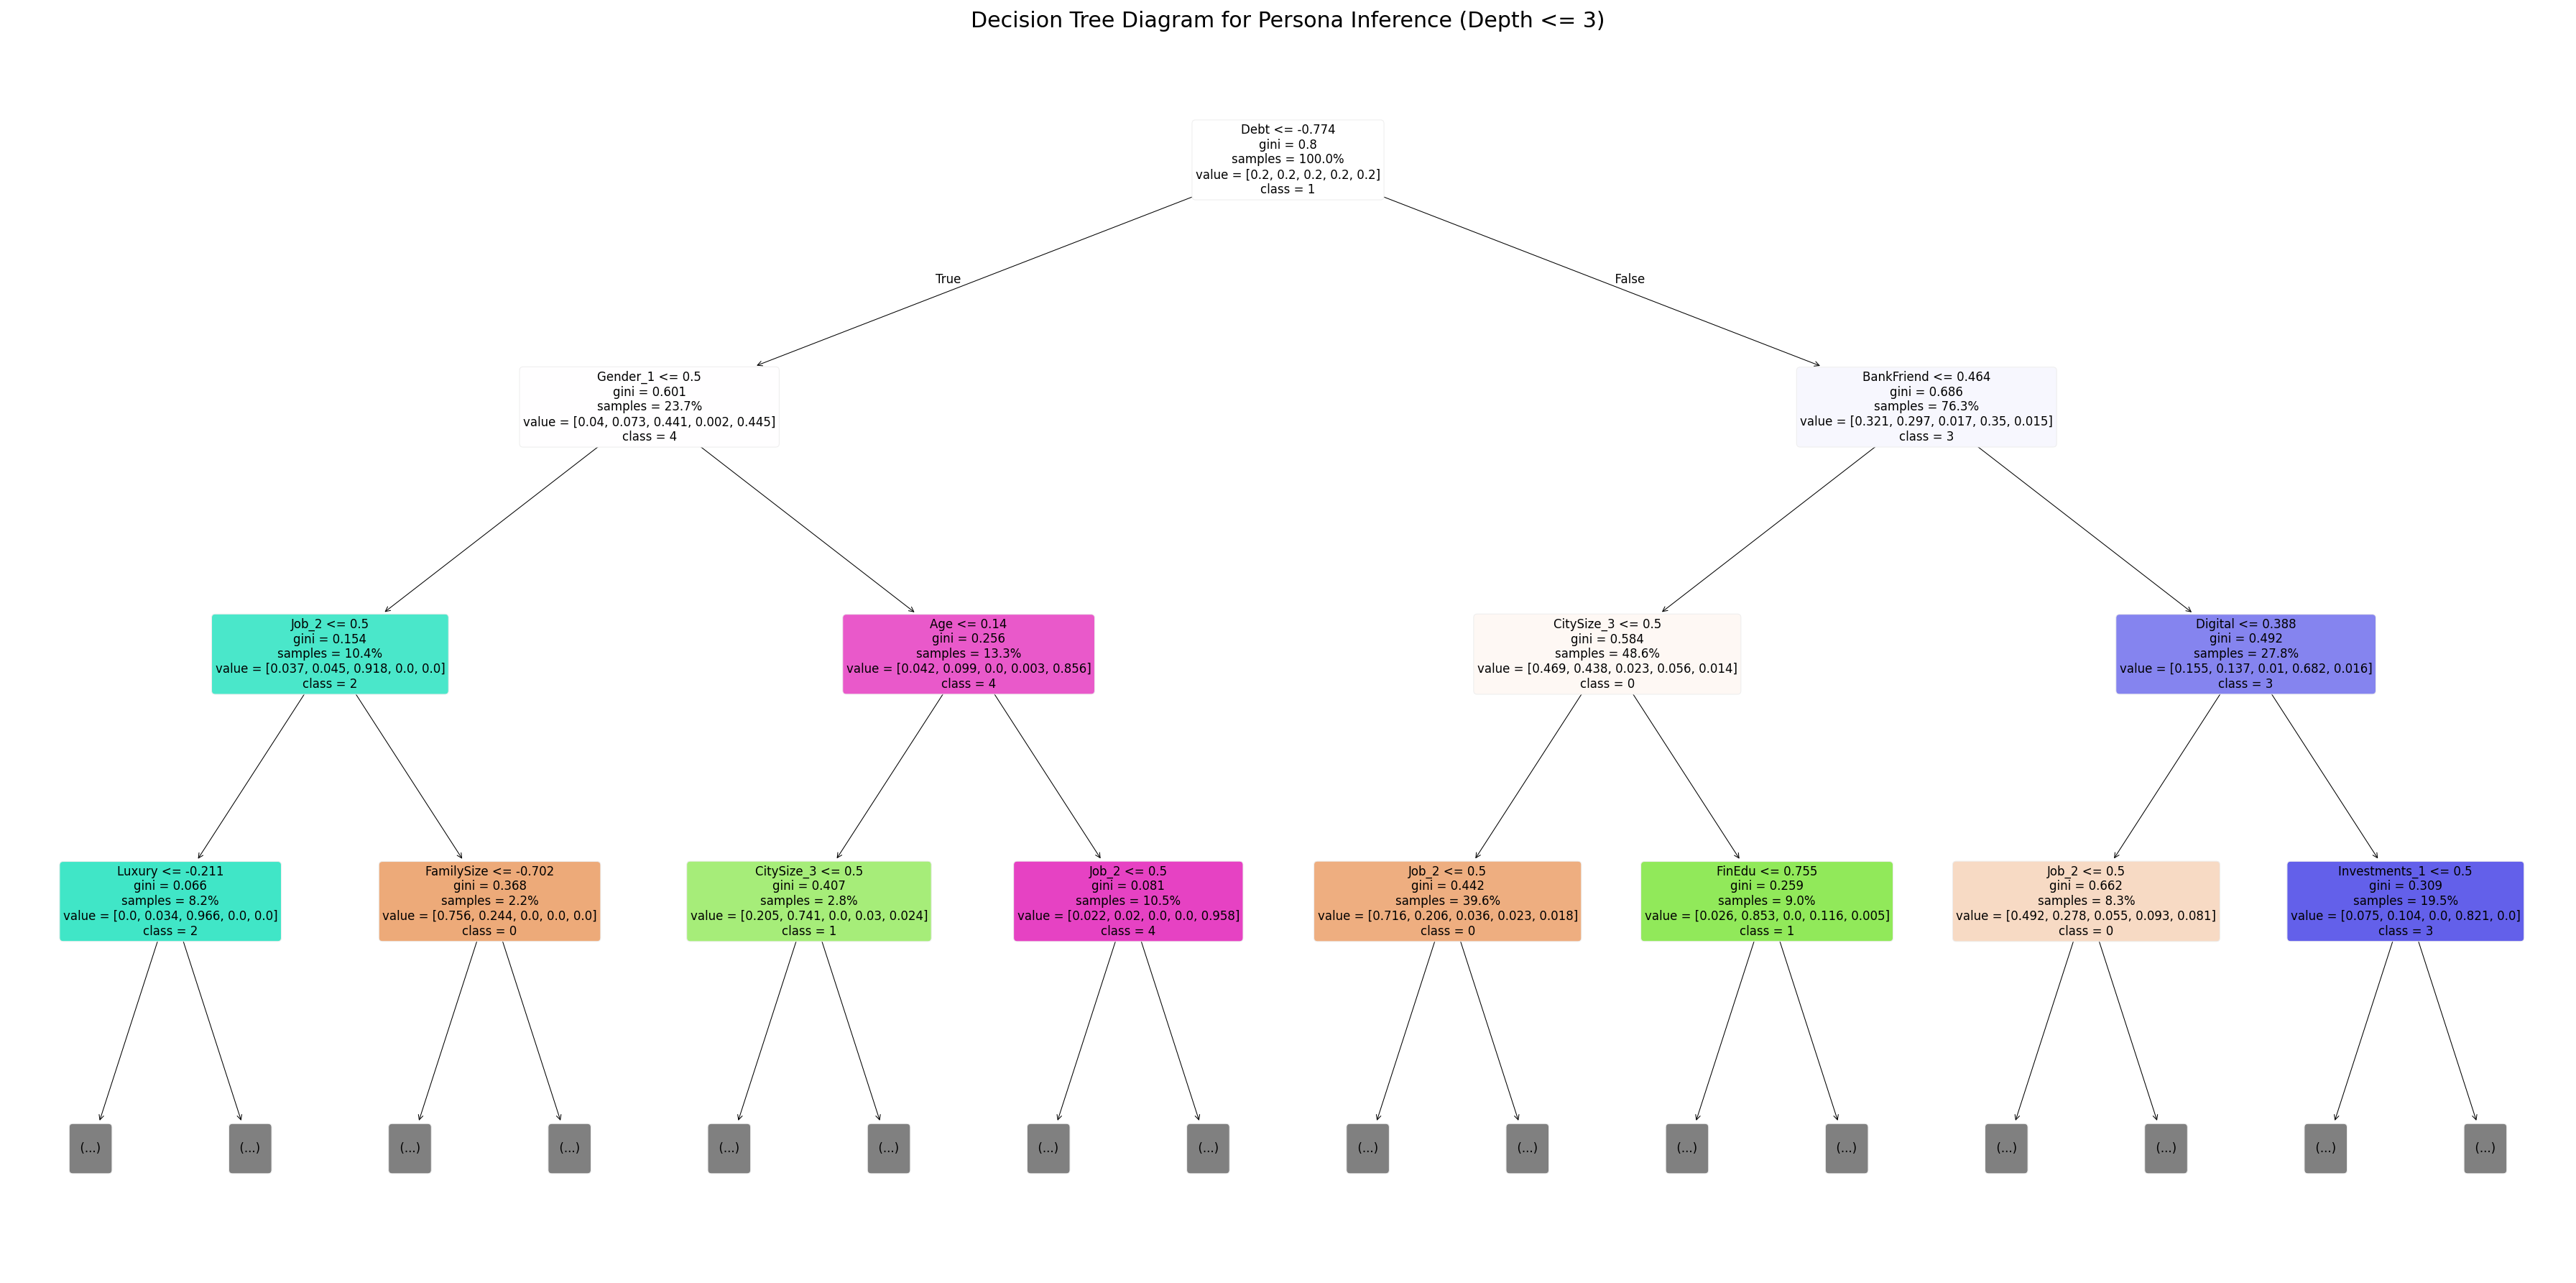

In [21]:
# Decision Tree diagram (limited depth for readability).
plt.figure(figsize=(24, 12))
plot_tree(
    dt_model,
    feature_names=feature_order,
    class_names=[str(c) for c in dt_model.classes_],
    filled=True,
    rounded=True,
    impurity=True,
    proportion=True,
    max_depth=3,
    fontsize=8,
)
plt.title("Decision Tree Diagram for Persona Inference (Depth <= 3)")
plt.tight_layout()
plt.savefig("result/persona_decision_tree_diagram.png", dpi=300, bbox_inches="tight")
plt.show()

While BGM and LVQ are excellent for discovery and interpretation, they are computationally heavy for real-time inference.

So we trained a Decision Tree Model. The tree successfully learned the underlying rules of the Bayesian clustering, achieving high accuracy on the holdout test set.
